In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('WineQT.csv')

In [3]:
df.shape

(1143, 13)

In [4]:
df = df.drop('Id',axis=1)

In [5]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [8]:
df = df.drop_duplicates()

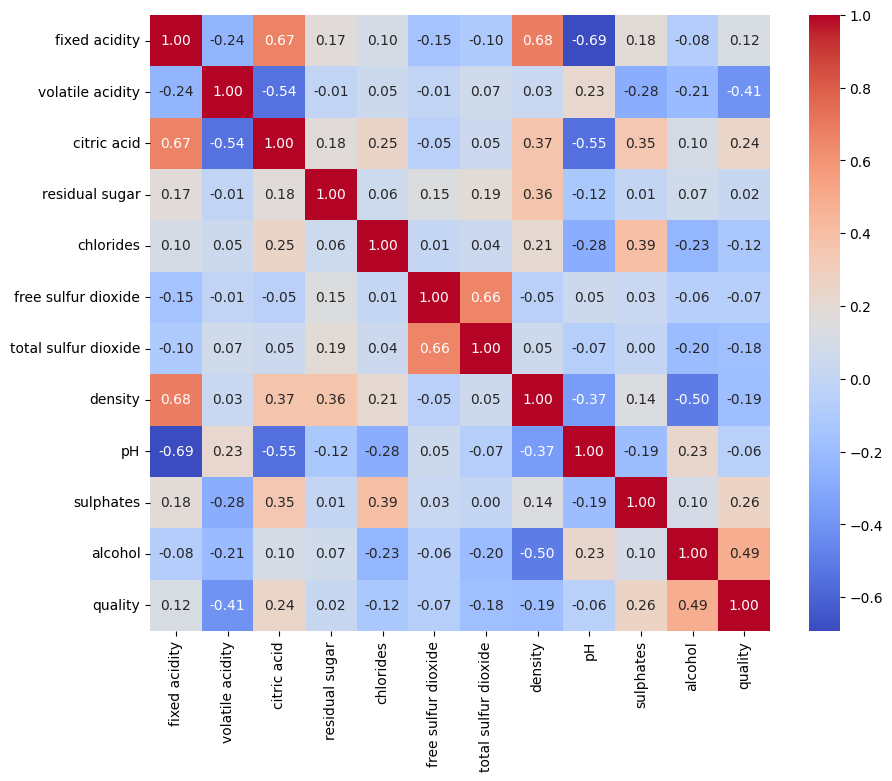

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True, fmt='.2f',cmap='coolwarm')
plt.show()

In [10]:
# df = df.drop(['residual sugar','free sulfur dioxide'],axis=1)

In [11]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


In [12]:
X = df.drop('quality',axis=1)
y = df['quality']

In [13]:
print(y.value_counts().sort_index())

quality
3      6
4     33
5    433
6    409
7    122
8     15
Name: count, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=2)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
y_train_smote.value_counts()

quality
6    346
5    346
7    346
4    346
3    346
8    346
Name: count, dtype: int64

In [16]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train_scale = ss.fit_transform(X_train_smote)
X_test_scale = ss.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report, f1_score
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train_scale,y_train_smote)

y_pred_test = lr.predict(X_test_scale)
y_pred_train = lr.predict(X_train_scale)
print('train accuracy: ',accuracy_score(y_train_smote, y_pred_train))
print('train precision: ',precision_score(y_train_smote, y_pred_train, average="weighted"))
print('f1 score train', f1_score(y_train_smote, y_pred_train,average="weighted"))
print("*"*10)

print('test accuracy: ',accuracy_score(y_test, y_pred_test))
print('test precision: ',precision_score(y_test, y_pred_test ,average="weighted"))
print(f1_score(y_test, y_pred_test,average="weighted"))

result = []
result.append({
    'model':'logistic',
    'accuracy train ': accuracy_score(y_train_smote, y_pred_train),
    'precision train': precision_score(y_train_smote, y_pred_train, average="weighted"),
    'f1 score train': f1_score(y_train_smote, y_pred_train,average="weighted"),
    'accuracy test': accuracy_score(y_test, y_pred_test),
    'precision test ':precision_score(y_test, y_pred_test ,average="weighted"),
    'f1 score ': f1_score(y_test, y_pred_test, average="weighted")
})

train accuracy:  0.6541425818882466
train precision:  0.6409581498979507
f1 score train 0.6448957594628337
**********
test accuracy:  0.37254901960784315
test precision:  0.5298636687829575
0.4189254284390922


In [18]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train_scale,y_train_smote)

y_pred_test = svm.predict(X_test_scale)
y_pred_train = svm.predict(X_train_scale)
print('train accuracy: ',accuracy_score(y_train_smote, y_pred_train))
print('train precision: ',precision_score(y_train_smote, y_pred_train, average='weighted'))
print('f1 score train', f1_score(y_train_smote, y_pred_train,average="weighted"),)
print("*"*10)

print('test accuracy: ',accuracy_score(y_test, y_pred_test))
print('test precision: ',precision_score(y_test, y_pred_test, average='weighted'))
print('f1 score',f1_score(y_test, y_pred_test,average="weighted"))

result.append({
    'model':'SVC',
    'accuracy train ': accuracy_score(y_train_smote, y_pred_train),
    'precision train': precision_score(y_train_smote, y_pred_train, average="weighted"),
    'f1 score train': f1_score(y_train_smote, y_pred_train,average="weighted"),
    'accuracy test': accuracy_score(y_test, y_pred_test),
    'precision test ':precision_score(y_test, y_pred_test ,average="weighted"),
    'f1 score ': f1_score(y_test, y_pred_test, average="weighted")
    
})

train accuracy:  0.8439306358381503
train precision:  0.8365593966691339
f1 score train 0.8380285452969708
**********
test accuracy:  0.45098039215686275
test precision:  0.5411364418175563
f1 score 0.4838414438743621


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier()
param_grid = [{
    'n_estimators':[51,101,151,201],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}]
grid =GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=3, scoring='f1_weighted')
grid.fit(X_train_smote, y_train_smote)

print(grid.best_params_)

y_pred_test = grid.predict(X_test)
y_pred_train = grid.predict(X_train_smote)
print('train accuracy: ',accuracy_score(y_train_smote, y_pred_train))
print('train precision: ',precision_score(y_train_smote, y_pred_train, average='weighted'))
print('f1 score train', f1_score(y_train_smote, y_pred_train,average="weighted"))
print("*"*10)

print('test accuracy: ',accuracy_score(y_test, y_pred_test))
print('test precision: ',precision_score(y_test, y_pred_test, average='weighted'))
print('f1 score:',f1_score(y_test, y_pred_test,average="weighted"))
result.append({
    'model':'RandomForest classifier',
    'accuracy train ': accuracy_score(y_train_smote, y_pred_train),
    'precision train': precision_score(y_train_smote, y_pred_train, average="weighted"),
     'f1 score train': f1_score(y_train_smote, y_pred_train,average="weighted"),
    'accuracy test': accuracy_score(y_test, y_pred_test),
    'precision test ':precision_score(y_test, y_pred_test ,average="weighted"),
    'f1 score ': f1_score(y_test, y_pred_test, average="weighted")
    
})


{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 151}
train accuracy:  0.9995183044315993
train precision:  0.9995196926032662
f1 score train 0.999518303425684
**********
test accuracy:  0.45588235294117646
test precision:  0.4680368150637683
f1 score: 0.4571311415559242


In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scale,y_train_smote)

y_pred_test = knn.predict(X_test_scale)
y_pred_train = knn.predict(X_train_scale)
print('train accuracy: ',accuracy_score(y_train_smote, y_pred_train))
print('train precision: ',precision_score(y_train_smote, y_pred_train, average='weighted',zero_division=0))
print('f1 score train', f1_score(y_train_smote, y_pred_train,average="weighted"))
print("*"*10)

print('test accuracy: ',accuracy_score(y_test, y_pred_test))
print('test precision: ',precision_score(y_test, y_pred_test, average='weighted',zero_division=0))
print('f1 score ', f1_score(y_test, y_pred_test, average="weighted"))

result.append({
    'model':'knn',
    'accuracy train ': accuracy_score(y_train_smote, y_pred_train),
    'precision train': precision_score(y_train_smote, y_pred_train, average="weighted"),
     'f1 score train': f1_score(y_train_smote, y_pred_train,average="weighted"),
    'accuracy test': accuracy_score(y_test, y_pred_test),
    'precision test ':precision_score(y_test, y_pred_test ,average="weighted"),
    'f1 score ': f1_score(y_test, y_pred_test, average="weighted")
    
})

train accuracy:  0.8521194605009634
train precision:  0.8448998402779618
f1 score train 0.8414407964837407
**********
test accuracy:  0.36764705882352944
test precision:  0.47234220028337676
f1 score  0.4049364112048097


In [21]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
y_train_encode = le.fit_transform(y_train_smote)#3,4,5,6,7,8 --> 0,1,2,3,4,5
y_test_encode = le.transform(y_test)

In [22]:
from xgboost import XGBClassifier


xgboost = XGBClassifier(n_estimators=101, max_depth=2, learning_rate = 0.05)

xgboost.fit(X_train_scale, y_train_encode)

y_pred_test = xgboost.predict(X_test)
y_pred_train = xgboost.predict(X_train_scale)

#back to original
y_pred_test_original = le.inverse_transform(y_pred_test)
y_pred_train_original = le.inverse_transform(y_pred_train)#0,1,2,3,4,5 --> 3,4,5,6,7,8


print('train accuracy: ',accuracy_score(y_train_smote, y_pred_train_original))
print('train precision: ',precision_score(y_train_smote, y_pred_train_original, average='weighted'))
print( 'f1 score train', f1_score(y_train_smote, y_pred_train_original,average="weighted"))
print("*"*10)

print('test accuracy: ',accuracy_score(y_test, y_pred_test_original))
print('test precision: ',precision_score(y_test, y_pred_test_original, average='weighted',zero_division=0))
print('f1 score ', f1_score(y_test, y_pred_test_original, average="weighted"))

result.append({
    'model':'XGboost',
    'accuracy train ': accuracy_score(y_train_smote, y_pred_train_original),
    'precision train': precision_score(y_train_smote, y_pred_train_original, average="weighted",zero_division=0),
    'f1 score train': f1_score(y_train_smote, y_pred_train_original,average="weighted"),
    'accuracy test': accuracy_score(y_test, y_pred_test_original),
    'precision test ':precision_score(y_test, y_pred_test_original ,average="weighted",zero_division=0),
    'f1 score ': f1_score(y_test, y_pred_test_original, average="weighted")
    
})

train accuracy:  0.7673410404624278
train precision:  0.7572438600677598
f1 score train 0.7545249944474155
**********
test accuracy:  0.39215686274509803
test precision:  0.17997936016511867
f1 score  0.2467143295344612


In [23]:
results = pd.DataFrame(result)
results

,model,accuracy train,precision train,f1 score train,accuracy test,precision test,f1 score
0,logistic,0.654143,0.640958,0.644896,0.372549,0.529864,0.418925
1,SVC,0.843931,0.836559,0.838029,0.450980,0.541136,0.483841
2,RandomForest classifier,0.999518,0.999520,0.999518,0.455882,0.468037,0.457131
3,knn,0.852119,0.844900,0.841441,0.367647,0.472342,0.404936
4,XGboost,0.767341,0.757244,0.754525,0.392157,0.179979,0.246714
